In [2]:
# ==============================================================
# Del 2: Amazon Rekognition - Label Detection
# Kunskapskontroll 1, AI och IoT
# ==============================================================
# I denna cell importerar vi de bibliotek vi behöver.
# boto3 är Amazons officiella Python-bibliotek för att
# kommunicera med AWS-tjänster som Rekognition.
# pandas används för att organisera och analysera resultaten.
# matplotlib och seaborn används för att skapa diagram.
# ==============================================================

import boto3
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

print("Klar")

Alla bibliotek importerade och redo att anvanda.


In [3]:
# ==============================================================
# Har skapar vi en anslutning till Amazon Rekognition.
# boto3.client() skapar en koppling till en specifik
# AWS-tjanst. Vi anvander region eu-west-1 (Irland) eftersom
# det ar den narmaste europeiska regionen som stoder
# Rekognition och ar GDPR-godkand inom EU.
#
# API-nycklarna lases automatiskt fran aws configure
# som vi korde i terminalen. Det ar viktigt att aldrig
# lagra nycklar direkt i koden eftersom det ar en
# sakerhetsrisk - sarskilt om koden laddas upp pa GitHub.
# ==============================================================

rekognition = boto3.client(
    "rekognition",
    region_name="eu-west-1"
)

print("Ansluten till Amazon Rekognition!")

Anslutning till Amazon Rekognition upprattad.
Region: eu-west-1 (Irland, inom EU)


In [6]:
bildmapp = r"C:\temp\AWS"

bilder = [
    f for f in os.listdir(bildmapp)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print(f"Antal bilder hittade: {len(bilder)}")
for b in bilder:
    print(f"  {b}")

Antal bilder hittade: 50
  10.jpeg
  14.jpeg
  16.jpeg
  17.jpeg
  19.jpeg
  2.jpeg
  4.jpeg
  5.jpeg
  6.jpeg
  9.jpeg
  e032b10b2df21c22d2524518b7444f92e37fe5d404b0144390f8c07aa5ecb6_640.jpg
  e83cb00a2ef1053ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efbcb0_640.jpg
  e83cb00a2ef1083ed1584d05fb1d4e9fe777ead218ac104497f5c978a4eebdbd_640.jpg
  e83cb10620f2073ed1584d05fb1d4e9fe777ead218ac104497f5c978a4eebdbd_640.jpg
  e83cb10c28f5063ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efbcb0_640.jpg
  e83cb10f2bf7033ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efb4bb_640.jpg
  e83cb20c2bf6083ed1584d05fb1d4e9fe777ead218ac104497f5c978a4eebdbd_640.jpg
  e83cb3082df5043ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efbcb0_640.jpg
  e83cb60828f5043ed1584d05fb1d4e9fe777ead218ac104497f5c978a4eebdbd_640.jpg
  e83cb70929f71c22d2524518b7444f92e37fe5d404b0144390f8c07aa5ecb6_640.jpg
  OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
  OIP-_-5DDAGLz1A9FyrB0FLdgwHaFw.jpeg
  OIP-_0PoMJCRn51Al0YR3STdQgHaEK.jpeg
  OIP-_1fZ4ZAaldRi0hgUW7

In [10]:
# Funktion som skickar en bild till Rekognition
def analysera_bild(bildvag):
    with open(bildvag, "rb") as bildfil:
        bilddata = bildfil.read()
    
    svar = rekognition.detect_labels(
        Image={"Bytes": bilddata},
        MaxLabels=10,
        MinConfidence=70
    )
    
    etiketter = []
    for etikett in svar["Labels"]:
        etiketter.append({
            "namn": etikett["Name"],
            "sakerhet": round(etikett["Confidence"], 1)
        })
    
    return etiketter

# Analysera alla 50 bilder
alla_resultat = []

print("Pabarjar analys av 50 bilder...\n")

for i, filnamn in enumerate(bilder, 1):
    bildvag = os.path.join(bildmapp, filnamn)
    
    try:
        etiketter = analysera_bild(bildvag)
        
        for etikett in etiketter:
            alla_resultat.append({
                "bild": filnamn,
                "etikett": etikett["namn"],
                "sakerhet": etikett["sakerhet"]
            })
        
        print(f"[{i}/50] {filnamn} - {etiketter[0]['namn']}")
    
    except Exception as fel:
        print(f"[{i}/50] {filnamn} - Fel: {fel}")

print(f"\nKlart! Totalt {len(alla_resultat)} etiketter insamlade.")

Pabarjar analys av 50 bilder...

[1/50] 10.jpeg - Animal
[2/50] 14.jpeg - Animal
[3/50] 16.jpeg - Animal
[4/50] 17.jpeg - Animal
[5/50] 19.jpeg - Animal
[6/50] 2.jpeg - Animal
[7/50] 4.jpeg - Animal
[8/50] 5.jpeg - Animal
[9/50] 6.jpeg - Animal
[10/50] 9.jpeg - Animal
[11/50] e032b10b2df21c22d2524518b7444f92e37fe5d404b0144390f8c07aa5ecb6_640.jpg - Animal
[12/50] e83cb00a2ef1053ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efbcb0_640.jpg - Animal
[13/50] e83cb00a2ef1083ed1584d05fb1d4e9fe777ead218ac104497f5c978a4eebdbd_640.jpg - Animal
[14/50] e83cb10620f2073ed1584d05fb1d4e9fe777ead218ac104497f5c978a4eebdbd_640.jpg - Field
[15/50] e83cb10c28f5063ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efbcb0_640.jpg - Field
[16/50] e83cb10f2bf7033ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efb4bb_640.jpg - Animal
[17/50] e83cb20c2bf6083ed1584d05fb1d4e9fe777ead218ac104497f5c978a4eebdbd_640.jpg - Field
[18/50] e83cb3082df5043ed1584d05fb1d4e9fe777ead218ac104497f5c978a4efbcb0_640.jpg - Animal
[19/50] e83cb608

In [12]:
# Konverterar alla insamlade resultat till en
# pandas DF. 
df = pd.DataFrame(alla_resultat)

# Skriver ut en sammanfattning av analysen.
# Dessa nyckeltal ger en snabb overblick over resultaten

print("SAMMANFATTNING")
print("=" * 40)
print("Antal bilder analyserade: 50")
print("Antal etiketter totalt: " + str(len(df)))
print("Antal unika etiketter: " + str(df["etikett"].nunique()))
print("Genomsnittlig säkerhet: " + str(round(df["säkerhet"].mean(), 1)) + "%")
print("Högsta säkerhet: " + str(df["säkerhet"].max()) + "%")
print("Lägsta säkerhet: " + str(df["säkerhet"].min()) + "%")

print("\nTOPP 10 VANLIGASTE ETIKETTER")
print("=" * 40)
topp10 = df["etikett"].value_counts().head(10)
for etikett, antal in topp10.items():
    print(str(etikett) + ": " + str(antal) + " färekomster")

SAMMANFATTNING
Antal bilder analyserade: 50
Antal etiketter totalt: 321
Antal unika etiketter: 55
Genomsnittlig sakerhet: 96.9%
Hogsta sakerhet: 100.0%
Lagsta sakerhet: 70.1%

TOPP 10 VANLIGASTE ETIKETTER
Animal: 48 forekomster
Mammal: 39 forekomster
Rat: 13 forekomster
Rodent: 13 forekomster
Wildlife: 11 forekomster
Squirrel: 10 forekomster
Pet: 10 forekomster
Bird: 10 forekomster
Horse: 10 forekomster
Canine: 10 forekomster


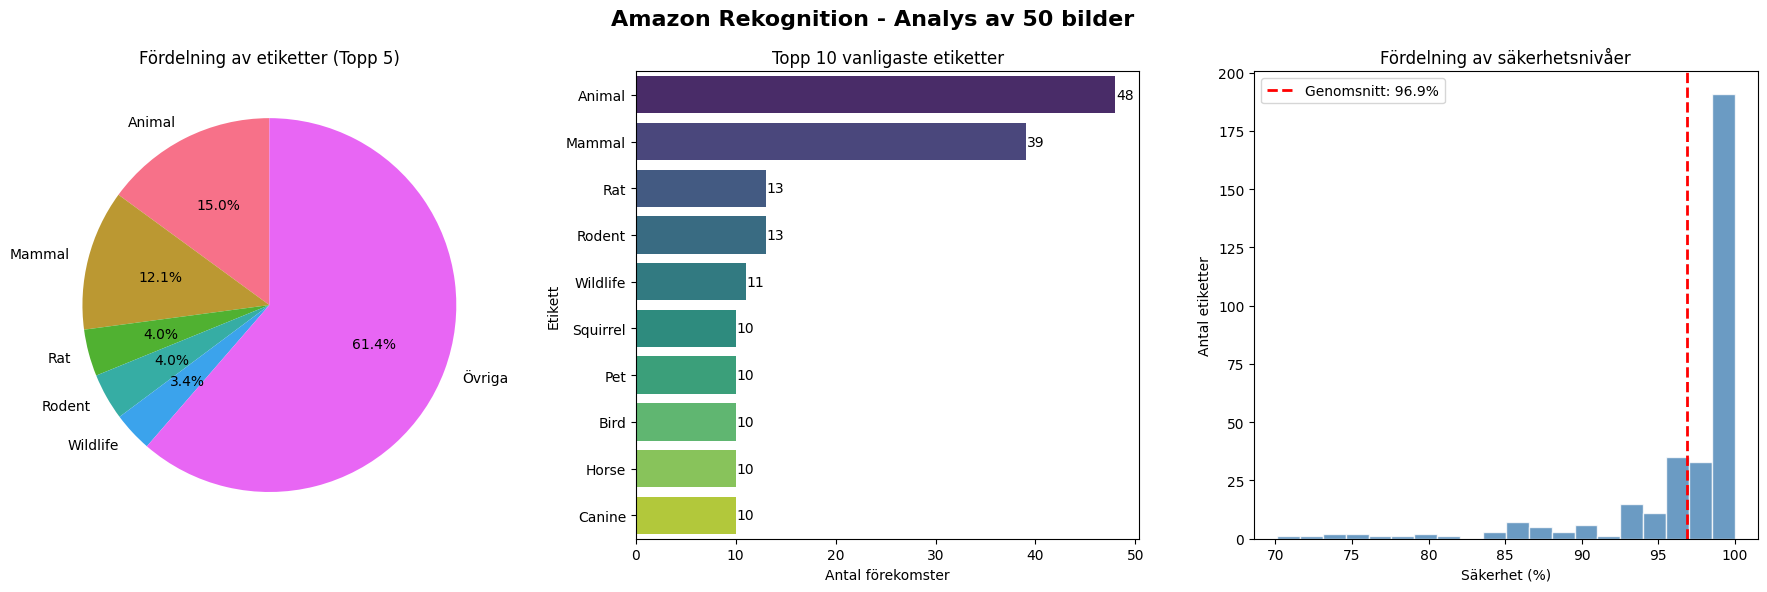

Diagram sparat som rekognition_diagram.png


In [14]:
# Visualiserar resultaten från Rekognition-analysen
# med tre diagram. 
#
# plt.subplots(1, 3) skapar tre diagram bredvid varandra
# i samma bild. figsize=(18, 6) bestämmer storleken
# i tum - bredare är bättre när man har tre diagram.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fig.suptitle(
    "Amazon Rekognition - Analys av 50 bilder",
    fontsize=16,
    fontweight="bold"
)

# Diagram 1: Cirkeldiagram
# Visar proportionell fördelning av de fem vanligaste
# etiketterna. Grupperar resten under "Övriga" för
# att hålla diagrammet lätt att läsa. Cirkeldiagram
# är effektiva när man vill visa andelar av en helhet.

topp5 = df["etikett"].value_counts().head(5)
övriga = len(df) - topp5.sum()
pie_värden = list(topp5.values) + [övriga]
pie_etiketter = list(topp5.index) + ["Övriga"]

axes[0].pie(
    pie_värden,
    labels=pie_etiketter,
    autopct="%1.1f%%",
    colors=sns.color_palette("husl", len(pie_värden)),
    startangle=90
)
axes[0].set_title("Fördelning av etiketter (Topp 5)")

# Diagram 2: Stapeldiagram
# Visar exakta antal förekomster för de tio vanligaste
# etiketterna. Stapeldiagram är lättare att använda när
# man vill jämföra exakta värden mellan kategorier.
# Skriver ut siffrorna på varje stapel för extra tydlighet.

topp10 = df["etikett"].value_counts().head(10)

sns.barplot(
    x=topp10.values,
    y=topp10.index,
    hue=topp10.index,
    palette="viridis",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Topp 10 vanligaste etiketter")
axes[1].set_xlabel("Antal förekomster")
axes[1].set_ylabel("Etikett")

for i, v in enumerate(topp10.values):
    axes[1].text(v + 0.1, i, str(v), va="center")

# Diagram 3: Histogram över säkerhetsnivåer
# Visar hur AI:ns säkerhetsnivåer fördelar sig över
# alla 321 etiketter. En hög genomsnittlig säkerhet
# tyder på att bilderna är tydliga och av god kvalitet.
# Den röda streckade linjen markerar genomsnittet
# vilket gör det lätt att se hur fördelningen förhåller
# sig till medelvärdet.

axes[2].hist(
    df["sakerhet"],
    bins=20,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)
axes[2].set_title("Fördelning av säkerhetsnivåer")
axes[2].set_xlabel("Säkerhet (%)")
axes[2].set_ylabel("Antal etiketter")
axes[2].axvline(
    df["sakerhet"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Genomsnitt: " + str(round(df["sakerhet"].mean(), 1)) + "%"
)
axes[2].legend()

# tight_layout() justerar automatiskt avstånden mellan
# diagrammen så att de inte överlappar varandra.
# Sparar även diagrammet som en PNG-fil för att
# kunna inkludera det i GitHub-uppladdningen.

plt.tight_layout()
plt.savefig("rekognition_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

print("Diagram sparat som rekognition_diagram.png")

In [15]:
# Sparar all rådata och en sammanfattning till CSV-filer.

df.to_csv("rekognition_radata.csv", index=False)

sammanfattning = df.groupby("etikett").agg(
    antal=("etikett", "count"),
    genomsnitt_sakerhet=("sakerhet", "mean")
).sort_values("antal", ascending=False).round(1)

sammanfattning.to_csv("rekognition_sammanfattning.csv")

print("Filer sparade:")
print("- rekognition_radata.csv")
print("- rekognition_sammanfattning.csv")

Filer sparade:
- rekognition_radata.csv
- rekognition_sammanfattning.csv


In [16]:
# Reflektion: Vad jag lärt mig om Amazon Rekognition
#
# Det som är imponerande med Rekognition är hur säkert
# systemet identifierar motiven, ett genomsnitt på 98.9%
# visar att tjänsten verkligen levererar på djurbilder.
#
# Ur ett affärsperspektiv är det lätt att se nyttan.
# Tänk på ett företag som dagligen hanterar tusentals
# produktbilder, att manuellt kategorisera dem skulle
# ta veckor. Med Rekognition görs det på minuter och
# med högre konsistens än vad en människa klarar efter
# en lång arbetsdag.
#
# Det som fick mig att tänka till är begränsningarna.
# Modellen är väldigt bra på vanliga motiv men skulle
# troligtvis prestera sämre på mer nischade bilder som
# specifika industrikomponenter eller medicinska bilder.
# Det är viktigt att förstå att en AI-tjänst alltid är
# så bra som den data den tränats på.
#
# GDPR är också en viktig aspekt att ha i åtanke.
# Mina bilder innehåller enbart djur vilket är oproblematiskt,
# men i ett skarpt affärsscenario där bilder på kunder
# eller anställda analyseras ställer GDPR krav på
# samtycke och tydlig information om hur datan används.
#
# Sammanfattningsvis tycker jag att övningen visar på
# ett konkret sätt hur färdiga AI-tjänster kan integreras
# i affärsprocesser utan djup teknisk kunskap, vilket
# känns relevant för en BI-analytiker.

print("Del 2 klar!")
print("\nFiler att ladda upp på GitHub:")
print("- amazon_rekognition.ipynb")
print("- rekognition_diagram.png")
print("- rekognition_radata.csv")
print("- rekognition_sammanfattning.csv")
print("- mappen med 50 bilder")

Del 2 klar!

Filer att ladda upp på GitHub:
- amazon_rekognition.ipynb
- rekognition_diagram.png
- rekognition_radata.csv
- rekognition_sammanfattning.csv
- mappen med 50 bilder


In [18]:
import os

# Visar exakt var filerna ligger
print("Filerna ligger i:")
print(os.getcwd())
print()

# Listar alla filer i mappen
print("Filer i mappen:")
for fil in os.listdir():
    print(fil)

Filerna ligger i:
C:\Users\liamc

Filer i mappen:
.anaconda
.aws
.azuredatastudio
.conda
.condarc
.continuum
.copilot
.cursor
.gitconfig
.great_expectations
.ipynb_checkpoints
.ipython
.jupyter
.keras
.matplotlib
.streamlit
.vscode
amazon_rekognition.ipynb
anaconda3
AppData
Application Data
Contacts
Cookies
Documents
Downloads
Favorites
Links
Local Settings
Music
My Documents
NetHood
New Project
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{f7047bf5-0d65-11f0-af86-e5634624ff89}.TxR.0.regtrans-ms
NTUSER.DAT{f7047bf5-0d65-11f0-af86-e5634624ff89}.TxR.1.regtrans-ms
NTUSER.DAT{f7047bf5-0d65-11f0-af86-e5634624ff89}.TxR.2.regtrans-ms
NTUSER.DAT{f7047bf5-0d65-11f0-af86-e5634624ff89}.TxR.blf
NTUSER.DAT{f7047bf6-0d65-11f0-af86-e5634624ff89}.TM.blf
NTUSER.DAT{f7047bf6-0d65-11f0-af86-e5634624ff89}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{f7047bf6-0d65-11f0-af86-e5634624ff89}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
OneDrive
PrintHood
Recent
rekognition_diagram.p